# 02 - Hyperparameter Tuning: XGBoost (Optuna)

XGBoost is our backup third candidate (Recall 0.6062 at default settings, statistically tied with LightGBM/CatBoost). Tuning it gives a fairer three-way comparison against the tuned Random Forest and Neural Network.


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")


X_train: (46026, 28), X_val: (7890, 28)


## 1. Define the Optuna search space and objective

In [2]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return recall_score(y_val, y_pred)


## 2. Run the study

In [3]:
import time

N_TRIALS = 50
start = time.time()

def progress_callback(study, trial):
    done = len(study.trials)
    elapsed = time.time() - start
    avg = elapsed / done
    remaining = avg * (N_TRIALS - done)
    print(
        f"Trial {done}/{N_TRIALS} | this trial: {trial.duration.total_seconds():.0f}s | "
        f"elapsed: {elapsed/60:.1f} min | ETA: {remaining/60:.1f} min | "
        f"best so far: {study.best_value:.4f}"
    )

study = optuna.create_study(direction='maximize', study_name='xgb_recall_tuning')
study.optimize(objective, n_trials=N_TRIALS, callbacks=[progress_callback])

print(f"Best validation Recall: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Trial 1/50 | this trial: 1s | elapsed: 0.0 min | ETA: 1.2 min | best so far: 0.5882
Trial 2/50 | this trial: 1s | elapsed: 0.0 min | ETA: 1.0 min | best so far: 0.5882
Trial 3/50 | this trial: 2s | elapsed: 0.1 min | ETA: 1.2 min | best so far: 0.5882
Trial 4/50 | this trial: 3s | elapsed: 0.1 min | ETA: 1.4 min | best so far: 0.6602
Trial 5/50 | this trial: 1s | elapsed: 0.1 min | ETA: 1.3 min | best so far: 0.6602
Trial 6/50 | this trial: 2s | elapsed: 0.2 min | ETA: 1.3 min | best so far: 0.6602
Trial 7/50 | this trial: 0s | elapsed: 0.2 min | ETA: 1.1 min | best so far: 0.6602
Trial 8/50 | this trial: 1s | elapsed: 0.2 min | ETA: 1.0 min | best so far: 0.6602
Trial 9/50 | this trial: 1s | elapsed: 0.2 min | ETA: 1.0 min | best so far: 0.6602
Trial 10/50 | this trial: 2s | elapsed: 0.3 min | ETA: 1.0 min | best so far: 0.6602
Trial 11/50 | this trial: 1s | elapsed: 0.3 min | ETA: 1.0 min | best so far: 0.6602
Trial 12/50 | this trial: 4s | elapsed: 0.3 min | ETA: 1.1 min | best so f

**What we found:**

**Tuned XGBoost reached a best validation Recall of 0.6773**, up from 0.6062 untuned (+7.1 points) and well above the tuned Random Forest's 0.6289 (+4.8 points). That is a much bigger gain than Random Forest got from tuning.

Two cautions before treating this as a clear win:

- **The objective was Recall alone, at the default 0.5 threshold, with no Precision requirement.** A model can raise Recall simply by leaning toward predicting "Late" more often, which costs Precision. So a higher Recall here does not by itself prove the model is better, only that it flags more late orders at this threshold. The evaluation cell at the bottom of this notebook checks Precision, F1, ROC-AUC, and PR-AUC. ROC-AUC and PR-AUC do not depend on the threshold, so they show whether the model genuinely ranks orders better or just shifted its operating point.
- **The best value is the best of 50 trials scored on one validation set,** so it is optimistic by construction. The test set in Notebook 06 is the honest check.

**Best parameters:** `n_estimators=490`, `max_depth=11`, `learning_rate=0.25`, `min_child_weight=8`, `gamma=0.26`, `subsample=0.88`, `colsample_bytree=0.86`, `reg_lambda=0.69`, `reg_alpha` close to zero. Two of these sit near the top of their search ranges (`n_estimators` near 500, `learning_rate` near 0.3), so a wider range might push slightly further. They are also fairly aggressive boosting settings, the kind more prone to fitting quirks of the validation set, which is another reason to wait for the test result.

**Runtime:** 50 trials took about 2.7 minutes, with individual trials taking a few seconds. The Random Forest search took about an hour. This is a concrete example of the speed advantage of modern boosting libraries discussed in the model development stage.


## 3. Visualize the tuning process

C:\Users\Ewis\AppData\Local\Temp\ipykernel_15412\4105251997.py:7: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


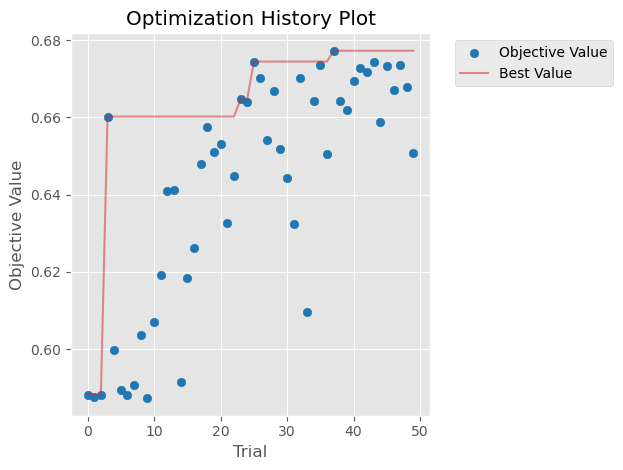

C:\Users\Ewis\AppData\Local\Temp\ipykernel_15412\4105251997.py:11: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


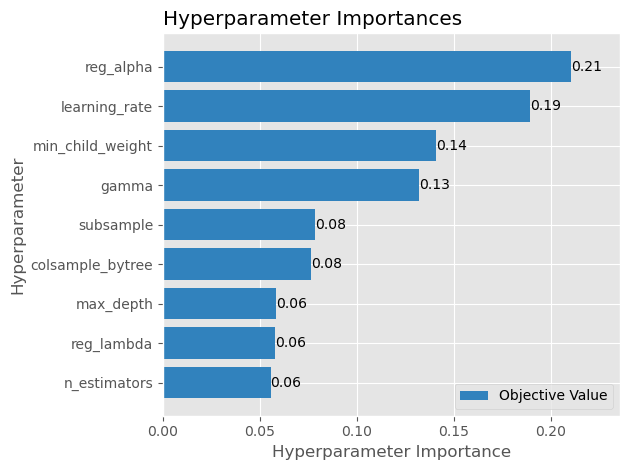

C:\Users\Ewis\AppData\Local\Temp\ipykernel_15412\4105251997.py:15: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
C:\Users\Ewis\AppData\Local\Temp\ipykernel_15412\4105251997.py:20: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


In [5]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances
)

plot_optimization_history(study)
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.show()

plot_optimization_history(study)
plt.savefig('../../../reports/figures/rf_optimization_history.png',
            dpi=120, bbox_inches='tight')
plt.close()

plot_param_importances(study)
plt.savefig('../../../reports/figures/rf_param_importance.png',
            dpi=120, bbox_inches='tight')
plt.close()

**What we found:**

**Optimization history:** the best value jumped early (about 0.660 by trial 4), then improved in two more steps, to about 0.674 around trial 26 and 0.677 around trial 38, and stayed flat after that. Later trials cluster between roughly 0.65 and 0.675, so many different settings perform about equally well. That suggests the search found a fairly flat top and more trials would add little.

**Parameter importance:** `reg_alpha` (0.21), `learning_rate` (0.19), `min_child_weight` (0.14), and `gamma` (0.13) matter most. Tree size and count (`max_depth`, `n_estimators`) matter least (0.06 each). In plain terms, how strongly the model is held back from fitting small patterns, and how fast it learns, moved Recall more than how big the trees are. This mirrors the Random Forest result, where `min_samples_split` and `min_samples_leaf` (also controls on how finely the trees split) dominated. Both models improved mainly by tuning how finely they fit, not how large they are.

**One reading note:** the best `reg_alpha` found was essentially zero, yet its importance is the highest. Importance measures how much the score varied as `reg_alpha` varied across trials, so this most likely means larger values hurt Recall and the search learned to avoid them. As with the Random Forest chart, treat these importances as a rough guide, since they are estimated from only 50 trials.


## 4. Retrain with best parameters and save

In [6]:
best_xgb = XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)

joblib.dump(best_xgb, '../../../models/xgboost_tuned.pkl')

import json
with open('../../../data/processed/optuna_xgb_best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

print("Saved tuned XGBoost and best parameters.")


Saved tuned XGBoost and best parameters.


## 5. Full validation metrics for the tuned model

The tuning objective was Recall only, so this checks what happened to everything else. Run the retrain cell above first, since this uses `best_xgb`.


In [7]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score

y_pred_tuned = best_xgb.predict(X_val)
y_score_tuned = best_xgb.predict_proba(X_val)[:, 1]

tuned = {
    'Recall': recall_score(y_val, y_pred_tuned),
    'Precision': precision_score(y_val, y_pred_tuned),
    'F1': f1_score(y_val, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_val, y_score_tuned),
    'PR-AUC': average_precision_score(y_val, y_score_tuned),
}
untuned = {'Recall': 0.6062, 'Precision': 0.8160, 'F1': 0.6956, 'ROC-AUC': 0.7595, 'PR-AUC': 0.8250}

comparison = pd.DataFrame({'Untuned XGBoost': untuned, 'Tuned XGBoost': tuned}).round(4)
comparison['Change'] = (comparison['Tuned XGBoost'] - comparison['Untuned XGBoost']).round(4)
comparison


,Untuned XGBoost,Tuned XGBoost,Change
Recall,0.6062,0.6773,0.0711
Precision,0.8160,0.7060,-0.1100
F1,0.6956,0.6913,-0.0043
ROC-AUC,0.7595,0.7405,-0.0190
PR-AUC,0.8250,0.8063,-0.0187
